# PrédiSinistre — Rendu 2 : Modélisation Avancée, Optimisation et Interprétabilité

**Projet :** Détection de fraude dans les réclamations d"assurance  
**Dataset :** `insurance_claims.csv` (1 000 sinistres, 40 variables)

---

## Principe fondamental : pas de fuite de données (Data Leakage)

L'ordre des opérations est **critique** en machine learning :

```
MAUVAIS ordre (data leakage)
   encodage(X_entier) → split(train/test)
   → Le test set contamine l"encodage du train set
   → Les performances mesurées sont trop optimistes

BON ordre (pipeline sklearn)
   split(train/test) → pipeline.fit(X_train) → pipeline.transform(X_test)
   → Le test set est totalement inconnu pendant le fit
   → Les performances reflètent le comportement réel en production
```

**Solution retenue : sklearn `Pipeline` + `ColumnTransformer`**
Cela garantit mécaniquement que le `fit` (apprentissage des encodages)
ne se fait **jamais** sur les données de test.

---

## Plan du notebook

1. Imports et Configuration
2. Chargement et Nettoyage
3. Feature Engineering
4. Split Train/Test — avant tout encodage
5. Construction du Pipeline (ColumnTransformer + modèle)
6. Gestion du déséquilibre des classes
7. Comparaison des modèles de boostage
8. Optimisation des hyperparamètres
9. Ajustement du seuil de décision
10. Interprétabilité (Permutation Importance + explications locales)
11. Évaluation finale
12. Sauvegarde du modèle

---
## 1. Importation de données et Configuration

In [34]:
# --- Import des packages --- 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, joblib, json
from collections import Counter

# --- Gestion des warnings ---
warnings.filterwarnings("ignore")
np.random.seed(42)

# --- Préprocessing et Pipeline ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# --- Split et Validation ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)

# --- Modèles ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier
)

# --- Métriques ---
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

# --- Modèles externes ---
try:
    import xgboost as xgb
    print("XGBoost:", xgb.__version__)
except ImportError:
    print("XGBoost non disponible")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non disponible — pip install shap")

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    print("imbalanced-learn disponible")
except ImportError:
    print("imbalanced-learn non disponible — pip install imbalanced-learn")

print("Imports chargés")

XGBoost: 3.2.0
imbalanced-learn disponible
Imports chargés


---
## 2. Chargement et Nettoyage de données

In [35]:
# Lecture des données
df = pd.read_csv("../data/raw/insurance_claims.csv")

# Taille des données
print(f"Shape initial : {df.shape}")
print(df["fraud_reported"].value_counts())
print(f"Taux de fraude : {(df["fraud_reported"]=="Y").mean():.1%}")

Shape initial : (1000, 40)
fraud_reported
N    753
Y    247
Name: count, dtype: int64
Taux de fraude : 24.7%


In [36]:
# ============================================================
# NETTOYAGE — Suppression des colonnes sans valeur prédictive
# ============================================================

# Colonnes à supprimer :
# - "_c39"             : colonne vide (artefact d"export CSV)
# - "policy_number"    : identifiant unique, aucune valeur prédictive
# - "incident_location": 1000 valeurs uniques, trop granulaire
# - "insured_zip"      : redondant avec incident_state


cols_to_drop = ["_c39", "policy_number",
    "incident_location", "insured_zip"
]

# Suppression des colonnes
df_clean = df.drop(columns=cols_to_drop)


# Encodage cible : Y=1 (fraude), N=0 (légitime) pour ne rester qu'avec des données numériques
df_clean["fraud_reported"] = (df_clean["fraud_reported"] == "Y").astype(int)

# Taille des données après nettoyage
print(f"Shape après suppression : {df_clean.shape}")
print(f"Valeurs manquantes : {df_clean.isnull().sum().sum()}")

Shape après suppression : (1000, 36)
Valeurs manquantes : 91


In [37]:
# ─────────────────────────────────────────────────────────────────
# Transformation des colonnes de dates
# ─────────────────────────────────────────────────────────────────
#
# Les dates brutes ne sont pas directement utilisables par les modèles ML.
# On extrait des features temporelles numériques interprétables :
#
#   policy_bind_date + incident_date → policy_age_years :
#     ancienneté de la police au moment du sinistre
#     (signal fort : police très récente avant un sinistre = suspect)
#
#   incident_date → incident_month, incident_dayofweek :
#     saisonnalité et patterns hebdomadaires de fraude
# ─────────────────────────────────────────────────────────────────

# Conversion en datetime (errors='coerce' transforme les invalides en NaT)
df_clean['policy_bind_date'] = pd.to_datetime(df_clean['policy_bind_date'], errors='coerce')
df_clean['incident_date']    = pd.to_datetime(df_clean['incident_date'],    errors='coerce')

# Ancienneté de la police en années au moment du sinistre
df_clean['policy_age_years'] = (
    (df_clean['incident_date'] - df_clean['policy_bind_date']).dt.days / 365.25
).round(2)

# Mois de l'incident (1-12) : saisonnalité
df_clean['incident_month'] = df_clean['incident_date'].dt.month

# Jour de la semaine (0=lundi, 6=dimanche) : patterns hebdomadaires
df_clean['incident_dayofweek'] = df_clean['incident_date'].dt.dayofweek

# Supprimer les colonnes dates originales (désormais encodées)
df_clean.drop(columns=['policy_bind_date', 'incident_date'], inplace=True)

# Vérification
print('Nouvelles features temporelles créées :')
print(df_clean[['policy_age_years', 'incident_month', 'incident_dayofweek']].describe().round(2))
print(f'\nShape après transformation dates : {df_clean.shape}')

Nouvelles features temporelles créées :
       policy_age_years  incident_month  incident_dayofweek
count           1000.00         1000.00             1000.00
mean              12.98            1.50                3.05
std                7.36            0.52                1.98
min               -0.05            1.00                0.00
25%                6.80            1.00                1.00
50%               12.82            1.00                3.00
75%               19.35            2.00                5.00
max               25.11            3.00                6.00

Shape après transformation dates : (1000, 37)


In [38]:
# ─────────────────────────────────────────────────────────────────
# Remplacement des '?' par NaN
# ─────────────────────────────────────────────────────────────────
#
# Les '?' sont une forme d'encodage de données manquantes propre
# à ce dataset. On les remplace par np.nan pour les traiter
# uniformément avec les outils pandas/sklearn d'imputation.
# ─────────────────────────────────────────────────────────────────

# Compter les '?' AVANT remplacement (pour comparaison)
q_before = {}
for col in df_clean.columns:
    if df_clean[col].dtype == object or str(df_clean[col].dtype) == 'string':
        q = (df_clean[col] == '?').sum()
        if q > 0:
            q_before[col] = q

print(f'Points d\'interrogation AVANT remplacement : {q_before}')

# Remplacement global de tous les '?' par NaN
df_clean.replace('?', np.nan, inplace=True)

print(f'\nValeurs NaN APRÈS remplacement :')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Points d'interrogation AVANT remplacement : {'collision_type': np.int64(178), 'property_damage': np.int64(360), 'police_report_available': np.int64(343)}

Valeurs NaN APRÈS remplacement :
collision_type             178
authorities_contacted       91
property_damage            360
police_report_available    343
dtype: int64


In [39]:
# ─────────────────────────────────────────────────────────────────
# Correction de umbrella_limit
# ─────────────────────────────────────────────────────────────────

# Vérification AVANT correction
n_neg = (df_clean['umbrella_limit'] < 0).sum()
print(f'Valeurs négatives AVANT correction : {n_neg}')
print(f'Valeur(s) concernée(s) : {sorted(df_clean[df_clean["umbrella_limit"] < 0]["umbrella_limit"].tolist())}')

# ── Correction : valeur absolue sur toute la colonne ──────────────
# abs() ne modifie que les négatifs ; les valeurs 0 et positives restent intactes
df_clean['umbrella_limit'] = df_clean['umbrella_limit'].abs()

# Vérification APRÈS correction
n_neg_after = (df_clean['umbrella_limit'] < 0).sum()
print(f'\nValeurs négatives APRÈS correction  : {n_neg_after}')
print('Distribution umbrella_limit (top 11) :')
print(df_clean['umbrella_limit'].value_counts().sort_index())
print('\numbrella_limit corrigée — aucune valeur négative restante.')

Valeurs négatives AVANT correction : 1
Valeur(s) concernée(s) : [-1000000]

Valeurs négatives APRÈS correction  : 0
Distribution umbrella_limit (top 11) :
umbrella_limit
0           798
1000000       1
2000000       3
3000000      12
4000000      39
5000000      46
6000000      57
7000000      29
8000000       8
9000000       5
10000000      2
Name: count, dtype: int64

umbrella_limit corrigée — aucune valeur négative restante.


In [40]:
# ─────────────────────────────────────────────────────────────────
# Imputation des valeurs manquantes
# ─────────────────────────────────────────────────────────────────

# Même méthodologie d'imputation que lors de l'analyse exploratoire de données (EDA) :

# ── ① authorities_contacted : NaN → 'None' ─────────────────────
df_clean['authorities_contacted'] = df_clean['authorities_contacted'].fillna('None')
print(f'authorities_contacted — NaN restants : {df_clean["authorities_contacted"].isnull().sum()}')

# ── ② collision_type : mode conditionnel à fraud_reported ────────
def mode_impute_conditional(series, condition_series):
    """Impute les NaN d'une série par le mode calculé sur chaque groupe
    défini par condition_series. Préserve le lien statistique avec la cible."""
    result = series.copy()
    for group_val in condition_series.unique():
        mask_group = condition_series == group_val
        mask_nan   = result.isnull() & mask_group
        if mask_nan.sum() == 0:
            continue
        # Mode du groupe (première valeur si ex-æquo)
        group_mode = result[mask_group].mode()
        if len(group_mode) > 0:
            result.loc[mask_nan] = group_mode[0]
    return result

df_clean['collision_type'] = mode_impute_conditional(
    df_clean['collision_type'], df_clean['fraud_reported']
)
print(f'collision_type         — NaN restants : {df_clean["collision_type"].isnull().sum()}')

# ── ③ property_damage : mode conditionnel à fraud_reported ─────────────────────────────
df_clean['property_damage'] = mode_impute_conditional(
    df_clean['property_damage'], df_clean['fraud_reported']
)
print(f'property_damage        — NaN restants : {df_clean["property_damage"].isnull().sum()}')

# ── ③ police_report_available : mode conditionnel à fraud_reported ──────────────────────
df_clean['police_report_available'] = mode_impute_conditional(
    df_clean['police_report_available'], df_clean['fraud_reported']
)
print(f'police_report_available— NaN restants : {df_clean["police_report_available"].isnull().sum()}')

# ── Vérification finale ──────────────────────────────────────────
total_nan = df_clean.isnull().sum().sum()
print(f'\nTotal valeurs manquantes après imputation : {total_nan}')

authorities_contacted — NaN restants : 0
collision_type         — NaN restants : 0
property_damage        — NaN restants : 0
police_report_available— NaN restants : 0

Total valeurs manquantes après imputation : 0


---
## 3. Feature Engineering

Ces ratios sont des **transformations arithmétiques déterministes** — ils ne dépendent
d'aucune statistique calculée sur les données (pas de moyenne, pas d'encodage).
Il est donc correct de les calculer avant le split.

> **Note sur la gestion de la division par zéro :**
> On utilise `.replace(0, np.nan).fillna(1)` plutôt que `+1`.
> Si le dénominateur est 0, le ratio vaut `valeur/1`, ce qui est
> plus explicite et sémantiquement correct que d'ajouter 1 à tous les dénominateurs.

In [41]:
TARGET = "fraud_reported"
X_raw = df_clean.drop(columns=[TARGET])
y     = df_clean[TARGET]

# Transformation artisanale de features pour capturer des signaux de fraude potentiels

# claim_ratio : montant réclamé / prime annuelle
# Ratio très élevé = réclamation suspecte par rapport à la couverture
X_raw["claim_ratio"] = (
    X_raw["total_claim_amount"]
    / X_raw["policy_annual_premium"].replace(0, np.nan).fillna(1)
)

# injury_share : part corporelle dans le total
# Les fraudes surestiment souvent les blessures (difficiles à vérifier)
X_raw["injury_share"] = (
    X_raw["injury_claim"]
    / X_raw["total_claim_amount"].replace(0, np.nan).fillna(1)
)

# vehicle_share : part véhicule dans le total
X_raw["vehicle_share"] = (
    X_raw["vehicle_claim"]
    / X_raw["total_claim_amount"].replace(0, np.nan).fillna(1)
)

# is_high_deductable : franchise élevée (binaire)
X_raw["is_high_deductable"] = (X_raw["policy_deductable"] > 1000).astype(int)

# Identification des types de colonnes
cat_cols = X_raw.select_dtypes(include="object").columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

# Affichage des ratios après transformation
print(f"claim_ratio : max={X_raw['claim_ratio'].max():.1f}, mean={X_raw['claim_ratio'].mean():.1f}")
print(f"injury_share : max={X_raw['injury_share'].max():.1f}, mean={X_raw['injury_share'].mean():.1f}")
print(f"vehicle_share : max={X_raw['vehicle_share'].max():.1f}, mean={X_raw['vehicle_share'].mean():.1f}\n")

# Affichage du nombre de features par type
print(f"Features numériques    : {len(num_cols)}")
print(f"Features catégorielles : {len(cat_cols)}")
print(f"Total avant encodage   : {X_raw.shape[1]}")

claim_ratio : max=158.0, mean=43.8
injury_share : max=0.3, mean=0.1
vehicle_share : max=1.0, mean=0.7

Features numériques    : 23
Features catégorielles : 17
Total avant encodage   : 40


---
## 4. Split Train / Test

**Règle d'or :** le split doit intervenir sur les données brutes,
avant toute transformation statistique. 

Tout ce qui suit (encodage, normalisation, imputation par statistiques) doit être appris
exclusivement sur `X_train`, puis appliqué à `X_test`.

In [42]:
# ====================================================================
# SPLIT STRATIFIÉ — SUR DONNÉES BRUTES
# stratify=y : conserver le ratio fraude/légitime dans chaque split
# ====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Afffichage des tailles et des taux de fraude dans chaque split
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Taux fraude train : {y_train.mean():.2%}")
print(f"Taux fraude test  : {y_test.mean():.2%}\n")
print("X_test mis de côté — aucun apprentissage ne le touchera avant l\'évaluation finale.")

X_train : (800, 40)  |  X_test : (200, 40)
Taux fraude train : 24.75%
Taux fraude test  : 24.50%

X_test mis de côté — aucun apprentissage ne le touchera avant l'évaluation finale.


---
## 5. Construction du Pipeline sklearn

Le `Pipeline` enchaîne `ColumnTransformer` (préprocessing) + classificateur.

- `pipeline.fit(X_train)` → **apprend** les encodages sur X_train uniquement
- `pipeline.predict(X_test)` → **applique** la transformation apprise, puis prédit
- `cross_val_score(pipeline, X_train)` → refitte le préprocessing à chaque fold correctement

C'est ce qui nous permet de garantir de façon mécanique le data leakage.

In [43]:
# ============================================================
# PREPROCESSEUR — ColumnTransformer
# Applique des transformations différentes par type de colonne
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        # Numériques : passage direct
        ("num", "passthrough", num_cols),

        # Catégorielles : One-Hot Encoding
        ("cat", OneHotEncoder(
            drop=None,
            handle_unknown="ignore",
            sparse_output=False
        ), cat_cols)
    ],
    remainder="drop"
)


def build_pipeline(classifier, use_smote=True):
    """
    Construit un pipeline complet :
    preprocessing -> SMOTE -> classificateur

    SMOTE est appliqué uniquement sur les folds TRAIN
    grâce à ImbPipeline, ce qui évite toute fuite de données.
    """

    steps = [
        ("preprocessor", preprocessor)
    ]

    # Application générique de SMOTE à tous les modèles
    if use_smote:
        steps.append(
            ("smote", SMOTE(random_state=42))
        )

    steps.append(
        ("classifier", classifier)
    )

    return ImbPipeline(steps)


# Fit du preprocessor sur X_train UNIQUEMENT pour récupérer les noms de features
# (utilisé plus tard pour l'interprétabilité)
_pp_fitted = preprocessor.fit(X_train)
ohe_feature_names = (
    _pp_fitted.named_transformers_["cat"]
    .get_feature_names_out(cat_cols).tolist()
)
feature_names_encoded = num_cols + ohe_feature_names

print(f"Features après encodage : {len(feature_names_encoded)}")
print(f"  Numériques  : {len(num_cols)}")
print(f"  OHE (cat)   : {len(ohe_feature_names)}")

# Modalités catégorielles pour le formulaire Streamlit
# Extraites de X_TRAIN uniquement (pas de fuite)
cat_modalities = {
    col: sorted(X_train[col].dropna().unique().tolist())
    for col in cat_cols
}
print("\nModalités extraites de X_train uniquement pour le formulaire Streamlit")


Features après encodage : 165
  Numériques  : 23
  OHE (cat)   : 142

Modalités extraites de X_train uniquement pour le formulaire Streamlit


---
## 6. Gestion du *déséquilibre* des Classes

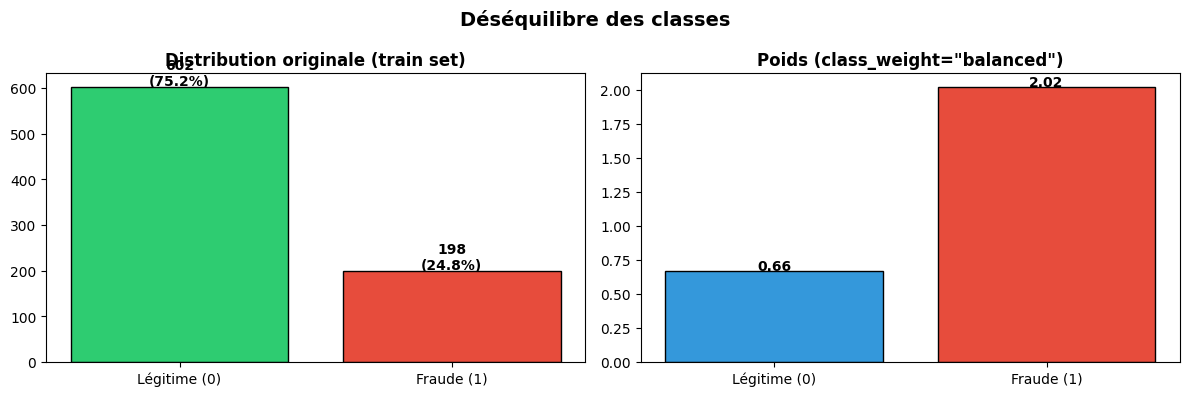

Poids : Légitime = 0.664, Fraude = 2.020


In [44]:
# ============================================================
# VISUALISATION DU DÉSÉQUILIBRE
# ============================================================

# Visualisation du déséquilibre de classes dans y_train et des poids calculés par compute_class_weight
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution originale dans y_train
counts = y_train.value_counts()
axes[0].bar(["Légitime (0)", "Fraude (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Distribution originale (train set)", fontweight="bold")
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, f"{v}\n({v/len(y_train):.1%})", ha="center", fontweight="bold")

# Poids calculés par compute_class_weight pour compenser le déséquilibre
weights = compute_class_weight("balanced", classes=np.array([0,1]), y=y_train)
axes[1].bar(["Légitime (0)", "Fraude (1)"], weights,
            color=["#3498db", "#e74c3c"], edgecolor="black")
axes[1].set_title('Poids (class_weight="balanced")', fontweight="bold")
for i, v in enumerate(weights):
    axes[1].text(i, v+0.01, f"{v:.2f}", ha="center", fontweight="bold")

# Ajustements esthétiques
plt.suptitle("Déséquilibre des classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Poids : Légitime = {weights[0]:.3f}, Fraude = {weights[1]:.3f}")

In [45]:
# ============================================================
# SMOTE GLOBAL VIA ImbPipeline
#
# SMOTE est maintenant intégré directement dans TOUS les pipelines.
#
# ORDRE GARANTI :
#   1. Split train/test
#   2. Preprocessing sur le fold train
#   3. Application de SMOTE UNIQUEMENT sur le train
#   4. Entraînement du modèle
#
# Grâce à ImbPipeline :
#   - aucune fuite de données
#   - SMOTE est automatiquement appliqué dans chaque fold CV
#   - tous les modèles utilisent la même logique de rééquilibrage
# ============================================================

example_pipeline = build_pipeline(
    HistGradientBoostingClassifier(random_state=42)
)

print(example_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['months_as_customer', 'age',
                                                   'policy_deductable',
                                                   'policy_annual_premium',
                                                   'umbrella_limit',
                                                   'capital-gains',
                                                   'capital-loss',
                                                   'incident_hour_of_the_day',
                                                   'number_of_vehicles_involved',
                                                   'bodily_injuries',
                                                   'witnesses',
                                                   'total_claim_amount',
                                                   'injury_claim',
                            

---
## 7. Comparaison des Modèles de Boostage

In [46]:
# ============================================================
# DÉFINITION DES PIPELINES CANDIDATS
# Chaque modèle est encapsulé dans un Pipeline complet
# cross_val_score(pipeline) va refitter le preprocessing correctement
#   à chaque fold sans fuite de données
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "LogisticRegression": build_pipeline(
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    ),
    "RandomForest": build_pipeline(
        RandomForestClassifier(n_estimators=200, class_weight="balanced",
                               random_state=42, n_jobs=-1)
    ),
    "AdaBoost": build_pipeline(
        # AdaBoost ne supporte pas class_weight → compenser via seuil
        AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
    ),
    "GradientBoosting": build_pipeline(
        # GradientBoosting ne supporte pas class_weight → compenser via seuil
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=4, subsample=0.8, random_state=42)
    ),
    "HistGradientBoosting": build_pipeline(
        HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                       max_depth=4, class_weight="balanced",
                                       random_state=42)
    ),
    "XGBoost" : build_pipeline(
        xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                          subsample=0.8, scale_pos_weight=3,
                          eval_metric="logloss", random_state=42)
    ),
}

print(f"Pipelines à évaluer : {list(pipelines.keys())}")

Pipelines à évaluer : ['LogisticRegression', 'RandomForest', 'AdaBoost', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost']


In [47]:
# ============================================================
# ÉVALUATION EN VALIDATION CROISÉE
#
# cross_val_score sur un Pipeline = le ColumnTransformer est
# refitté à chaque fold UNIQUEMENT sur les données du fold train.
# C'est la garantie que la CV est elle-même sans fuite.
# ============================================================

# Dictionnaire pour stocker les résultats de chaque modèle
results = {}

print("\n" + "="*68)
print(f"{"Modèle":<25} {"ROC-AUC":>12} {"F1":>12} {"Recall":>12}")
print("="*68)

# Parcour du pipeline, entrainement sur les données du train brut et stockage des scores
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)  # fit sur X_train brut
    auc_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    f1_cv  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    rec_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="recall")

    results[name] = {
        "pipeline"   : pipe,
        "auc_mean"   : auc_cv.mean(),  "auc_std"   : auc_cv.std(),
        "f1_mean"    : f1_cv.mean(),   "f1_std"    : f1_cv.std(),
        "recall_mean": rec_cv.mean(),  "recall_std": rec_cv.std()
    }
    print(f"{name:<25} "
          f"{auc_cv.mean():.4f}±{auc_cv.std():.3f}  "
          f"{f1_cv.mean():.4f}±{f1_cv.std():.3f}  "
          f"{rec_cv.mean():.4f}±{rec_cv.std():.3f}")

print("="*68)


Modèle                         ROC-AUC           F1       Recall
LogisticRegression        0.5970±0.050  0.3846±0.036  0.5767±0.084
RandomForest              0.9126±0.016  0.6472±0.037  0.5556±0.060
AdaBoost                  0.9209±0.018  0.7262±0.034  0.7022±0.074
GradientBoosting          0.9206±0.012  0.7394±0.042  0.7123±0.060
HistGradientBoosting      0.9182±0.018  0.7411±0.057  0.7276±0.079
XGBoost                   0.9134±0.018  0.7540±0.052  0.7935±0.086


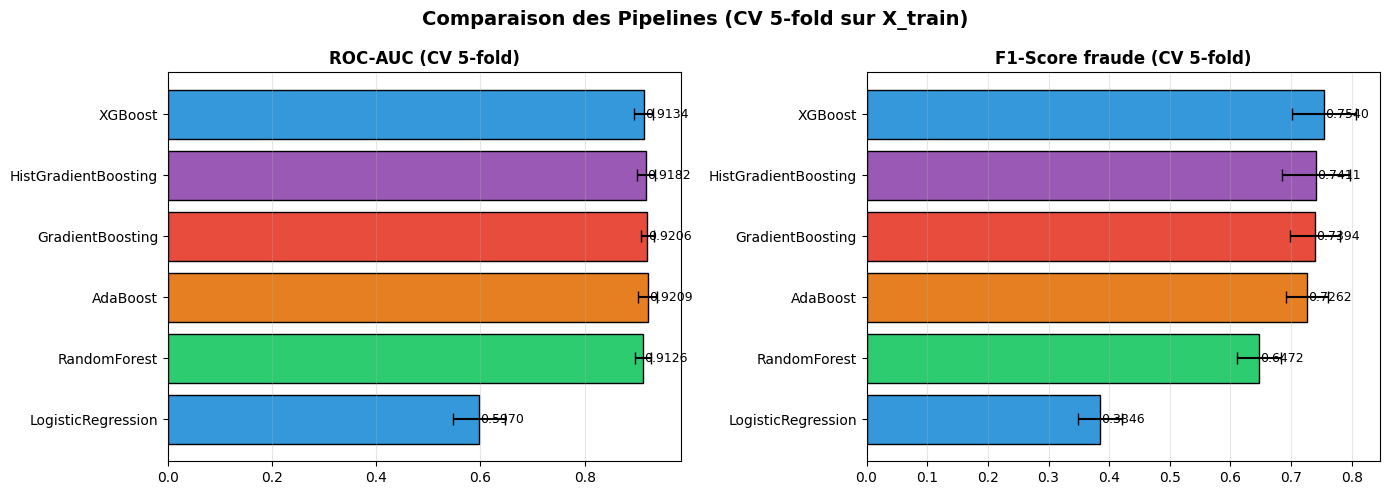

In [48]:
# ============================================================
# VISUALISATION — Comparaison des Pipelines
# ============================================================

# Visualisation des scores ROC-AUC et F1-Score avec barres d'erreur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = list(results.keys())
colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c", "#9b59b6"]

# Affichage des scores avec barres d'erreur
for ax, (m_key, s_key), label in zip(
    axes,
    [("auc_mean","auc_std"), ("f1_mean","f1_std")],
    ["ROC-AUC (CV 5-fold)", "F1-Score fraude (CV 5-fold)"]
):
    means = [results[m][m_key] for m in model_names]
    stds  = [results[m][s_key] for m in model_names]
    bars  = ax.barh(model_names, means, xerr=stds,
                    color=colors[:len(model_names)], capsize=4, edgecolor="black")
    ax.set_title(label, fontweight="bold")
    for bar, val in zip(bars, means):
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Comparaison des Pipelines (CV 5-fold sur X_train)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Optimisation des Hyperparamètres

Avec un Pipeline, les hyperparamètres du classificateur sont préfixés par `classifier__`.
Ex : `n_estimators` → `classifier__n_estimators`.

GridSearchCV / RandomizedSearchCV appliquent eux aussi le Pipeline complet
à chaque fold interne → aucune fuite, même lors de l"optimisation.

In [49]:
# ============================================================
# OPTIMISATION — HistGradientBoosting (RandomizedSearchCV)
# ============================================================

# Dictionnaire d'hyperparamètres à explorer pour HistGradientBoosting
hgb_param_dict = {
    "classifier__max_iter"         : [100, 200, 300],
    "classifier__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth"        : [3, 4, 5, 6],
    "classifier__min_samples_leaf" : [10, 20, 30],
    "classifier__l2_regularization": [0.0, 0.1, 1.0],
}

# 50 combinaisons × 5 folds = 250 entraînements → quelques minutes
print("RandomizedSearchCV — HistGradientBoosting (50 combinaisons × 5 folds)...")
hgb_search = RandomizedSearchCV(
    estimator=build_pipeline(
        HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
    ),
    param_distributions = hgb_param_dict,
    n_iter=50, cv=cv, scoring="roc_auc",
    n_jobs=-1, random_state=42, verbose=1
)

# Fit du RandomizedSearchCV sur X_train brut
hgb_search.fit(X_train, y_train)
print(f"\nMeilleurs hyperparamètres : {hgb_search.best_params_}")
print(f"   ROC-AUC CV : {hgb_search.best_score_:.4f}")

RandomizedSearchCV — HistGradientBoosting (50 combinaisons × 5 folds)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits



Meilleurs hyperparamètres : {'classifier__min_samples_leaf': 10, 'classifier__max_iter': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 0.1}
   ROC-AUC CV : 0.9289


In [50]:
# ============================================================
# OPTIMISATION — GradientBoosting (GridSearchCV)
# ============================================================

# Dictionnaire d'hyperparamètres à explorer pour GradientBoosting
gb_param_grid = {
    "classifier__n_estimators"  : [100, 200],
    "classifier__learning_rate" : [0.05, 0.1],
    "classifier__max_depth"     : [3, 4, 5],
    "classifier__subsample"     : [0.7, 0.9],
    "classifier__max_features"  : ["sqrt", 0.5],
}

# 72 combinaisons × 5 folds = 360 entraînements → quelques minutes
print(f"GridSearchCV — GradientBoosting ({2*3*3*2*2} combinaisons × 5 folds)...")
gb_search = GridSearchCV(
    estimator=build_pipeline(GradientBoostingClassifier(random_state=42)),
    param_grid=gb_param_grid,
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)

# Fit du GridSearchCV sur X_train brut
gb_search.fit(X_train, y_train)
print(f"\nMeilleurs hyperparamètres : {gb_search.best_params_}")
print(f"   ROC-AUC CV : {gb_search.best_score_:.4f}")

GridSearchCV — GradientBoosting (72 combinaisons × 5 folds)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Meilleurs hyperparamètres : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__max_features': 0.5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.9}
   ROC-AUC CV : 0.9261


In [51]:
# ============================================================
# OPTIMISATION — XGBoost (GridSearchCV)
# ============================================================

# Dictionnaire d'hyperparamètres à explorer pour XGBoost
xgb_param_grid = {
    "classifier__n_estimators"  : [100, 200],
    "classifier__learning_rate" : [0.05, 0.1],
    "classifier__max_depth"     : [3, 4, 5],
    "classifier__subsample"     : [0.7, 0.9],
    "classifier__max_features"  : ["sqrt", 0.5],
    "classifier__eval_metric"   : ["logloss", "default"],
    "classifier__scale_pos_weight" : [3, 5]
}

# 72 combinaisons × 5 folds = 360 entraînements → quelques minutes
print(f"GridSearchCV — XGBoost ({2*3*3*2*2} combinaisons × 5 folds)...")
xgb_search = GridSearchCV(
    estimator=build_pipeline(xgb.XGBClassifier(random_state=42)),
    param_grid=xgb_param_grid,
    cv=cv, scoring="roc_auc", 
    n_jobs=-1, verbose=1
)

# Fit du GridSearchCV sur X_train brut
xgb_search.fit(X_train, y_train)
print(f"\nMeilleurs hyperparamètres : {xgb_search.best_params_}")
print(f"   ROC-AUC CV : {xgb_search.best_score_:.4f}")

GridSearchCV — XGBoost (72 combinaisons × 5 folds)...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Meilleurs hyperparamètres : {'classifier__eval_metric': 'logloss', 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 3, 'classifier__subsample': 0.9}
   ROC-AUC CV : 0.9228


In [52]:
# ============================================================
# SÉLECTION DU CHAMPION — Évaluation sur X_test (une seule fois)
# ============================================================

# Récupération des meilleurs pipelines de chaque modèle optimisé
best_hgb_pipe = hgb_search.best_estimator_
best_gb_pipe  = gb_search.best_estimator_
best_xgb_pipe = xgb_search.best_estimator_

# Évaluation finale sur X_test (une seule fois) pour sélectionner le champion
auc_hgb = roc_auc_score(y_test, best_hgb_pipe.predict_proba(X_test)[:, 1])
auc_gb  = roc_auc_score(y_test, best_gb_pipe.predict_proba(X_test)[:, 1])
auc_xgb  = roc_auc_score(y_test, best_xgb_pipe.predict_proba(X_test)[:, 1])

# Affichage des scores AUC sur X_test pour les trois modèles optimisés
print(f"HistGradientBoosting AUC test : {auc_hgb:.4f}")
print(f"GradientBoosting     AUC test : {auc_gb:.4f}")
print(f"XGBoost              AUC test : {auc_xgb:.4f}")

# Sélection du champion en fonction de l'AUC sur X_test
if auc_hgb >= auc_gb:
    best_pipeline, y_prob_best, best_model_name = best_hgb_pipe, best_hgb_pipe.predict_proba(X_test)[:,1], "HistGradientBoosting"
elif auc_hgb <= auc_xgb:
    best_pipeline, y_prob_best, best_model_name = best_xgb_pipe, best_xgb_pipe.predict_proba(X_test)[:, 1], "XGBoost"
else:
    best_pipeline, y_prob_best, best_model_name = best_gb_pipe,  best_gb_pipe.predict_proba(X_test)[:,1],  "GradientBoosting"

# Affichage du champion et de son AUC sur X_test
print(f"\n🏆 Champion : {best_model_name} (AUC={max(auc_hgb,auc_gb, auc_xgb):.4f})")

HistGradientBoosting AUC test : 0.9099
GradientBoosting     AUC test : 0.8958
XGBoost              AUC test : 0.9090

🏆 Champion : HistGradientBoosting (AUC=0.9099)


---
## 9. Ajustement du Seuil de Décision

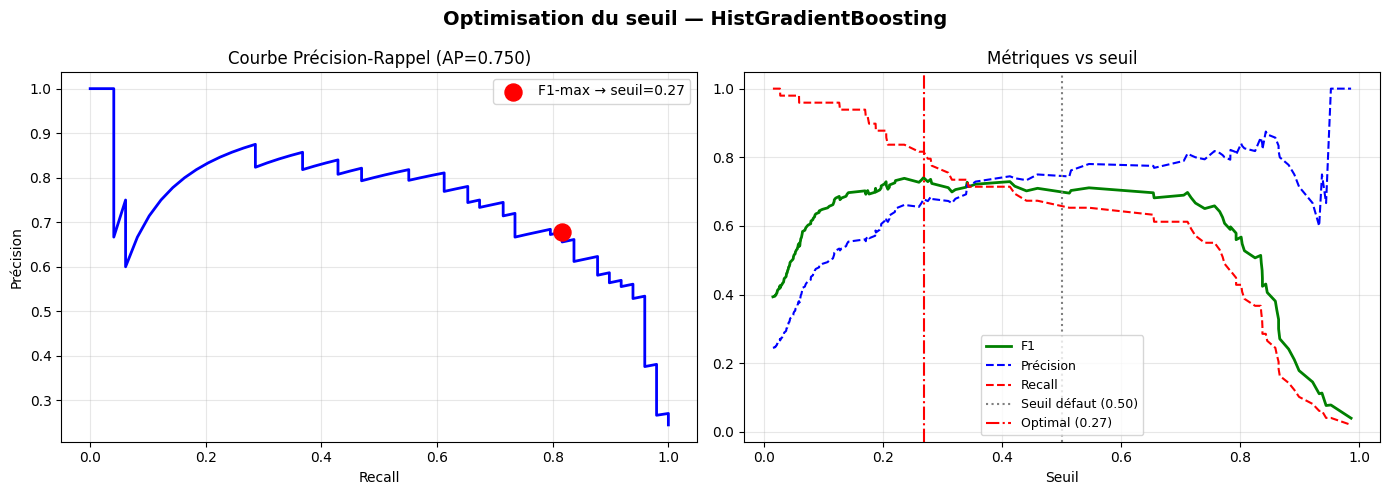


Seuil     Précision     Recall         F1
------------------------------------------
0.50         0.7442     0.6531     0.6957
0.27         0.6780     0.8163     0.7407 ← optimal


In [53]:
# ============================================================
# SEUIL OPTIMAL — Maximisation du F1-score
# ============================================================

# Calcul des courbes de précision-recall pour différents seuils
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_best)
f1_thresh = 2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
idx_best  = np.argmax(f1_thresh)
optimal_threshold = thresholds[idx_best]

# Visualisation de la courbe précision-recall et des métriques en fonction du seuil
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ap = average_precision_score(y_test, y_prob_best)
axes[0].plot(recall_vals, precision_vals, "b-", linewidth=2)
axes[0].scatter(recall_vals[idx_best], precision_vals[idx_best], s=150, c="red", zorder=5,
               label=f"F1-max → seuil={optimal_threshold:.2f}")
axes[0].set(xlabel="Recall", ylabel="Précision",
            title=f"Courbe Précision-Rappel (AP={ap:.3f})")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_thresh,            "g-",  label="F1",        linewidth=2)
axes[1].plot(thresholds, precision_vals[:-1],  "b--", label="Précision",  linewidth=1.5)
axes[1].plot(thresholds, recall_vals[:-1],     "r--", label="Recall",     linewidth=1.5)
axes[1].axvline(0.5,               color="gray", ls=":",  label="Seuil défaut (0.50)")
axes[1].axvline(optimal_threshold, color="red",  ls="-.", label=f"Optimal ({optimal_threshold:.2f})")
axes[1].set(xlabel="Seuil", title="Métriques vs seuil")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Ajustements esthétiques
plt.suptitle(f"Optimisation du seuil — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Affichage des métriques à seuil 0.5 et au seuil optimal
print(f"\n{"Seuil":<8} {"Précision":>10} {"Recall":>10} {"F1":>10}")
print("-"*42)
for thresh in [0.5, optimal_threshold]:
    yp = (y_prob_best >= thresh).astype(int)
    mark = " ← optimal" if thresh == optimal_threshold else ""
    print(f"{thresh:<8.2f} "
          f"{precision_score(y_test,yp,zero_division=0):>10.4f} "
          f"{recall_score(y_test,yp):>10.4f} "
          f"{f1_score(y_test,yp):>10.4f}{mark}")

---
## 10. Interprétabilité

Calcul Permutation Importance...


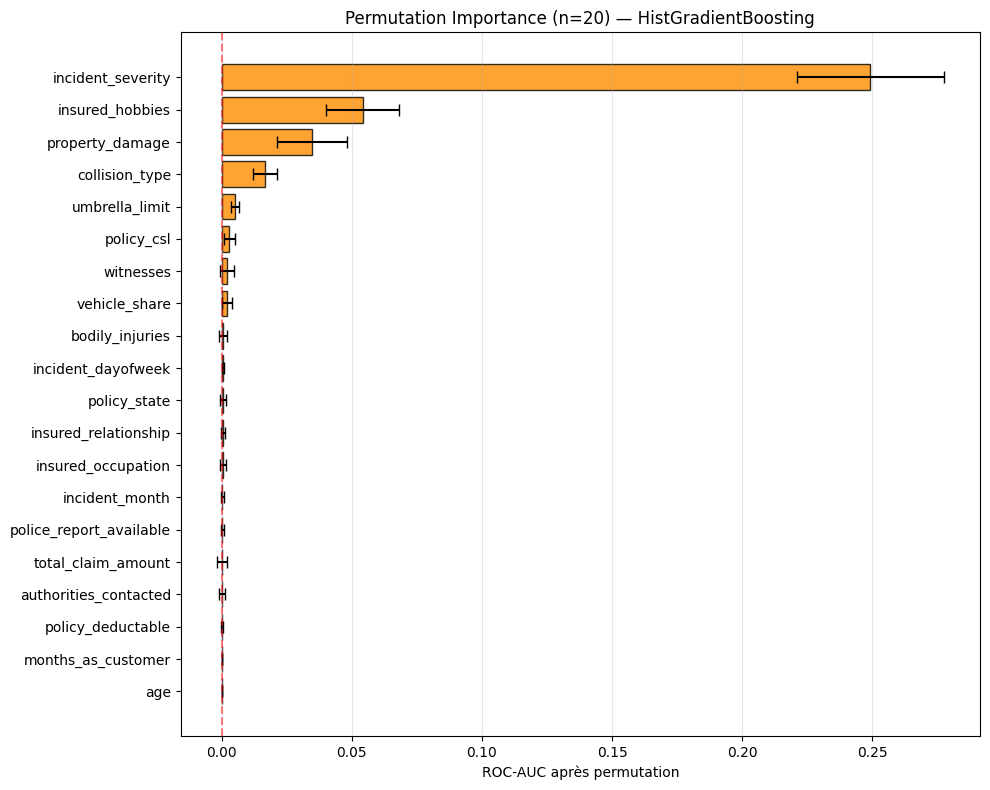

In [54]:
# ============================================================
# PERMUTATION IMPORTANCE
#
# On passe X_test BRUT au Pipeline complet :
# la permutation se fait sur les features originales (avant encodage),
# ce qui mesure l"impact réel de chaque variable métier.
# ============================================================

# Permutation Importance sur X_test brut pour mesurer l'impact réel de chaque feature métier
print("Calcul Permutation Importance...")
perm_imp = permutation_importance(
    best_pipeline, X_test, y_test,  # Pipeline complet + X_test brut
    n_repeats=20, random_state=42, scoring="roc_auc", n_jobs=-1
)

# DataFrame pour visualiser les résultats de la permutation importance
perm_df = pd.DataFrame({
    "feature"        : X_test.columns.tolist(),
    "importance_mean": perm_imp.importances_mean,
    "importance_std" : perm_imp.importances_std
}).sort_values("importance_mean", ascending=False)

# Visualisation de la permutation importance (top 20) avec barres d'erreur
top_p = perm_df.head(20).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_p["feature"], top_p["importance_mean"], xerr=top_p["importance_std"],
        color="darkorange", edgecolor="black", alpha=0.8, capsize=4)
ax.axvline(x=0, color="red", ls="--", alpha=0.5)
ax.set(xlabel="ROC-AUC après permutation",
       title=f"Permutation Importance (n=20) — {best_model_name}")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

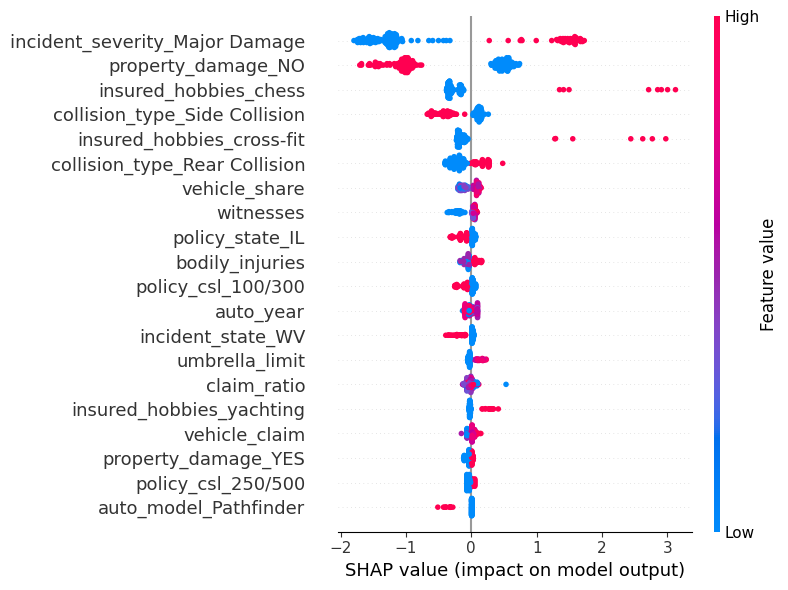

In [55]:
# Explication de la prédiction avec SHAP OFFICIELLE
X_test_tr = best_pipeline["preprocessor"].transform(X_test)
shap_explainer = shap.TreeExplainer(model=best_pipeline["classifier"])
shap_values = shap_explainer(X_test_tr)

# Représentation graphique summary_plot avec SHAP
shap.summary_plot(
    shap_values=shap_values, 
    features=X_test_tr, 
    feature_names=feature_names_encoded,
    plot_size=(8, 6)
    )

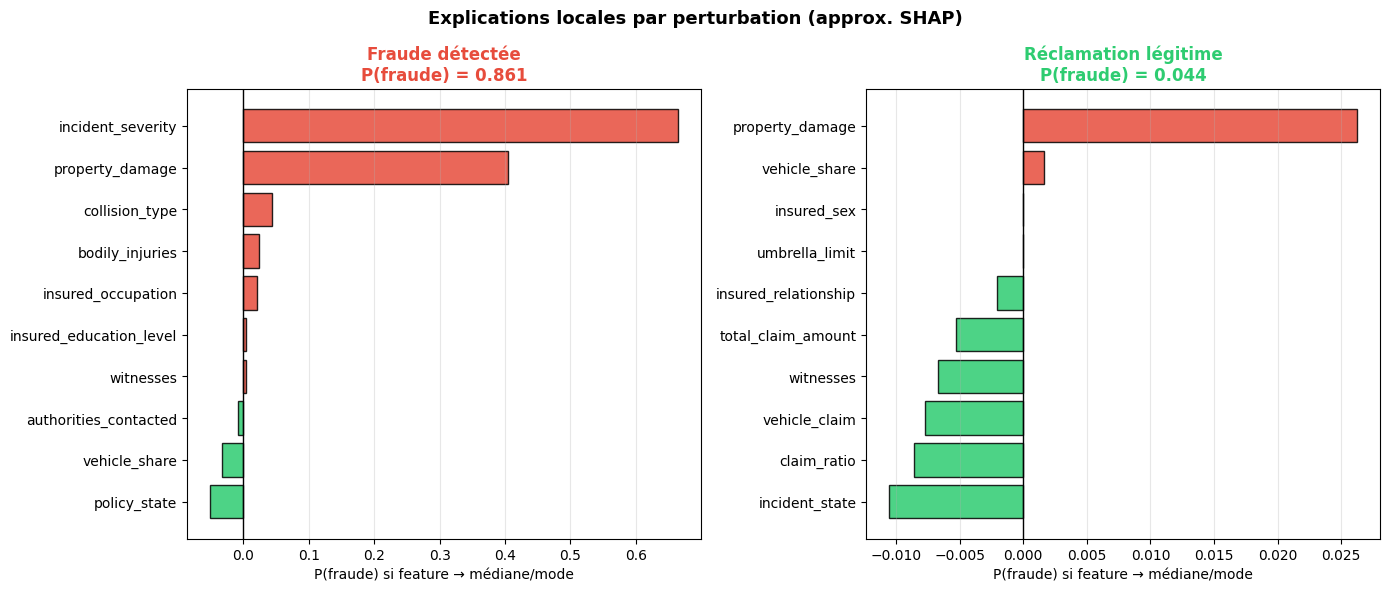

In [56]:
# ============================================================
# EXPLICATIONS LOCALES — Approximation SHAP par perturbation
#
# Pour chaque feature, on la remplace par sa valeur médiane/modale
# dans X_train et on mesure le Δ P(fraude).
# → contribution > 0 : la feature augmente le risque de fraude
# → contribution < 0 : la feature diminue le risque de fraude
# ============================================================


# Fonction d'explication locale par perturbation (approximation SHAP)
def explain_local(pipeline, X_instance_df, X_train_ref, n_top=10):
    """
    Explique la prédiction d'une instance par perturbation vers la médiane.
    
    Pour chaque feature :
    - Numériques  → remplacée par la médiane de X_train
    - Catégorielles → remplacée par le mode de X_train
    La contribution = P(fraude)_original - P(fraude)_perturbé
    """
    base_prob = pipeline.predict_proba(X_instance_df)[0, 1]
    contributions = []
    for col in X_instance_df.columns:
        X_pert = X_instance_df.copy()
        X_pert[col] = X_train_ref[col].mode()[0] if X_train_ref[col].dtype == object \
                      else X_train_ref[col].median()
        contributions.append(base_prob - pipeline.predict_proba(X_pert)[0, 1])
    return base_prob, pd.DataFrame({"feature": X_instance_df.columns, "contribution": contributions})\
                       .sort_values("contribution", key=abs, ascending=False).head(n_top)


# Visualisation des explications locales pour une instance de fraude et une instance légitime
fraud_idx = y_test[y_test == 1].index[0]
legit_idx = y_test[y_test == 0].index[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, label, color in zip(
    axes, [fraud_idx, legit_idx],
    ["Fraude détectée", "Réclamation légitime"],
    ["#e74c3c", "#2ecc71"]
):
    prob, contrib = explain_local(best_pipeline, X_test.loc[[idx]], X_train)
    sc = contrib.sort_values("contribution")
    ax.barh(sc["feature"], sc["contribution"],
            color=["#e74c3c" if v > 0 else "#2ecc71" for v in sc["contribution"]],
            edgecolor="black", alpha=0.85)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"{label}\nP(fraude) = {prob:.3f}", fontweight="bold", color=color, fontsize=12)
    ax.set_xlabel("P(fraude) si feature → médiane/mode")
    ax.grid(axis="x", alpha=0.3)

# Ajustements esthétiques
plt.suptitle("Explications locales par perturbation (approx. SHAP)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [57]:
# Explication de la prédiction par individu
shap_explainer = shap.TreeExplainer(model=best_pipeline["classifier"])
shap_values = shap_explainer(X_test_tr)

# Chargerment de la visualisation JS dans le notebook
shap.initjs()

# Choix de l'individu
i = 10
   
# Visualisation de l'impact des variables sur l'individu i
shap.plots.force(shap_values[i])

#shap.plots.bar(shap_values[i])
#shap.plots.waterfall(shap_values[i])

---
## 11. Évaluation Finale

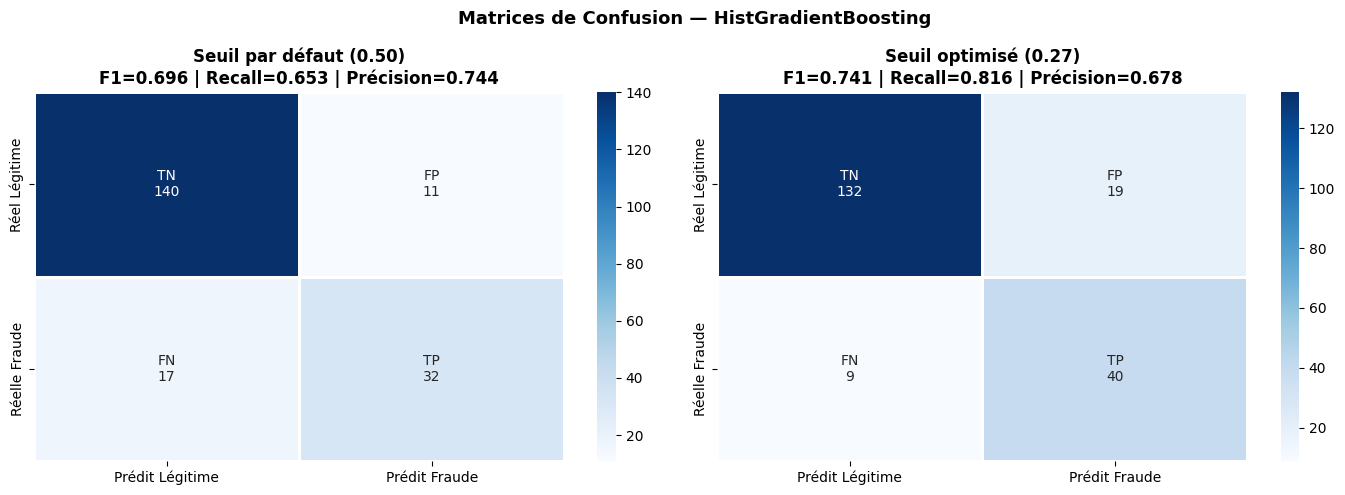


Rapport final (seuil optimisé) :
              precision    recall  f1-score   support

    Légitime       0.94      0.87      0.90       151
      Fraude       0.68      0.82      0.74        49

    accuracy                           0.86       200
   macro avg       0.81      0.85      0.82       200
weighted avg       0.87      0.86      0.86       200



In [58]:
# ============================================================
# MATRICES DE CONFUSION — Seuil 0.5 vs seuil optimal
# ============================================================

# Prédictions binaires avec seuil par défaut (0.5) et seuil optimisé
y_pred_default = (y_prob_best >= 0.5).astype(int)
y_pred_optimal = (y_prob_best >= optimal_threshold).astype(int)


# Visualisation des matrices de confusion pour les deux seuils
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(
    axes, [y_pred_default, y_pred_optimal],
    [f"Seuil par défaut (0.50)", f"Seuil optimisé ({optimal_threshold:.2f})"]
):
    cm = confusion_matrix(y_test, y_pred)
    labels = [[f"TN\n{cm[0,0]}", f"FP\n{cm[0,1]}"], [f"FN\n{cm[1,0]}", f"TP\n{cm[1,1]}"]]
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues",
               xticklabels=["Prédit Légitime","Prédit Fraude"],
               yticklabels=["Réel Légitime","Réelle Fraude"], ax=ax, linewidths=1)
    ax.set_title(
        f"{title}\nF1={f1_score(y_test,y_pred):.3f} | "
        f"Recall={recall_score(y_test,y_pred):.3f} | "
        f"Précision={precision_score(y_test,y_pred,zero_division=0):.3f}",
        fontweight="bold"
    )
    
# Ajustements esthétiques    
plt.suptitle(f"Matrices de Confusion — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Affichage du rapport de classification pour les deux seuils
print("\nRapport final (seuil optimisé) :")
print(classification_report(y_test, y_pred_optimal, target_names=["Légitime","Fraude"]))

In [59]:
# Tableau récapitulatif final
print("\n" + "="*70)
print(f"{"Modèle":<27} {"AUC":>8} {"F1":>8} {"Recall":>8} {"Précision":>10}")
print("="*70)
for name, res in results.items():
    pipe = res["pipeline"]
    yp   = pipe.predict_proba(X_test)[:, 1]
    ypred = pipe.predict(X_test)
    marker = " 🏆" if name == best_model_name else ""
    print(f"{name+marker:<29} "
          f"{roc_auc_score(y_test,yp):.4f}  "
          f"{f1_score(y_test,ypred):.4f}  "
          f"{recall_score(y_test,ypred):.4f}  "
          f"{precision_score(y_test,ypred,zero_division=0):.4f}")
print("-"*70)
print(f"{best_model_name+" (seuil opt)":<29} "
      f"{roc_auc_score(y_test,y_prob_best):.4f}  "
      f"{f1_score(y_test,y_pred_optimal):.4f}  "
      f"{recall_score(y_test,y_pred_optimal):.4f}  "
      f"{precision_score(y_test,y_pred_optimal,zero_division=0):.4f}")
print("="*70)


Modèle                           AUC       F1   Recall  Précision
LogisticRegression            0.6051  0.4151  0.6735  0.3000
RandomForest                  0.9066  0.6506  0.5510  0.7941
AdaBoost                      0.8934  0.7191  0.6531  0.8000
GradientBoosting              0.8959  0.6739  0.6327  0.7209
HistGradientBoosting 🏆        0.9009  0.6742  0.6122  0.7500
XGBoost                       0.8988  0.6735  0.6735  0.6735
----------------------------------------------------------------------
HistGradientBoosting (seuil opt) 0.9099  0.7407  0.8163  0.6780


---
## 12. Sauvegarde du Modèle

In [60]:
# ============================================================
# SAUVEGARDE DU PIPELINE COMPLET
#
# On sauvegarde le Pipeline COMPLET (préprocessing + modèle).
# Le Streamlit n'a qu'à faire :
#   pipeline = joblib.load("best_pipeline.pkl")
#   pipeline.predict_proba(X_brut)  ← X brut, pas encodé
#
# Le Pipeline gère l"encodage automatiquement en interne.
# ============================================================

# Sauvegarde du pipeline complet, des noms de features encodées, des modalités catégorielles et des métadonnées
joblib.dump(best_pipeline, "best_pipeline.pkl")
print("best_pipeline.pkl  — Pipeline complet (préprocessing + modèle)")

joblib.dump(feature_names_encoded, "feature_names.pkl")
print("feature_names.pkl  — Noms des features encodées (pour interprétabilité)")

# Modalités extraites de X_TRAIN uniquement (pas de fuite)
joblib.dump(cat_modalities, "cat_modalities.pkl")
print("cat_modalities.pkl — Modalités catégorielles (depuis X_train)")

# Méta-données du modèle et du dataset pour le Streamlit
metadata = {
    "model_name"       : best_model_name,
    "optimal_threshold": float(optimal_threshold),
    "roc_auc_test"     : float(roc_auc_score(y_test, y_prob_best)),
    "f1_test"          : float(f1_score(y_test, y_pred_optimal)),
    "recall_test"      : float(recall_score(y_test, y_pred_optimal)),
    "precision_test"   : float(precision_score(y_test, y_pred_optimal, zero_division=0)),
    "features_count"   : len(feature_names_encoded),
    "train_size"       : len(y_train),
    "test_size"        : len(y_test),
    "fraud_rate_train" : float(y_train.mean()),
    "num_cols"         : num_cols,
    "cat_cols"         : cat_cols
}

# Sauvegarde des métadonnées dans un fichier JSON pour une lecture facile dans le Streamlit
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("model_metadata.json — Métriques et configuration")

# Stats numériques du TRAIN SET uniquement (pour les sliders Streamlit)
num_stats = {
    col: {"min": float(X_train[col].min()), "max": float(X_train[col].max()),
          "mean": float(X_train[col].mean()), "std": float(X_train[col].std())}
    for col in num_cols if col in X_train.columns
}
with open("num_stats.json", "w") as f:
    json.dump(num_stats, f, indent=2)
print("num_stats.json      — Stats numériques du train set")

# Affichage du résumé final avec les métriques du champion sur X_test
print(f"\nRésumé final ({best_model_name}) :")
print(f"   ROC-AUC    : {metadata["roc_auc_test"]:.4f}")
print(f"   F1 (fraude): {metadata["f1_test"]:.4f}")
print(f"   Recall     : {metadata["recall_test"]:.4f}")
print(f"   Seuil opt  : {metadata["optimal_threshold"]:.3f}")

best_pipeline.pkl  — Pipeline complet (préprocessing + modèle)
feature_names.pkl  — Noms des features encodées (pour interprétabilité)
cat_modalities.pkl — Modalités catégorielles (depuis X_train)
model_metadata.json — Métriques et configuration
num_stats.json      — Stats numériques du train set

Résumé final (HistGradientBoosting) :
   ROC-AUC    : 0.9099
   F1 (fraude): 0.7407
   Recall     : 0.8163
   Seuil opt  : 0.268
